# Paul Tol's colorblind-friendly palettes — a tour via the FFT

This notebook walks through every palette in `benes_tools.colors` and shows the
most natural use-case for each. The Fourier transform is used as a running
example because it gives us:

- **categorical** signals (a few labelled curves) → qualitative palettes
- **non-negative magnitudes / power** → sequential palettes
- **signed real parts** → diverging palettes
- **a parameter family** → smooth rainbow

We finish with the AVHRR land-cover palette on a synthetic map.

> All palettes are from Paul Tol's technical note —
> https://sronpersonalpages.nl/~pault/ — and are designed to stay
> distinguishable for the three common forms of colour vision deficiency.

In [1]:
# Import the colors module directly to avoid pulling the package __init__
# (which currently imports si_units).
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve() / 'benes_tools'))
import tols_colors as tol

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

## 1. A tour of every palette

Each row is one palette, drawn as a strip of swatches.

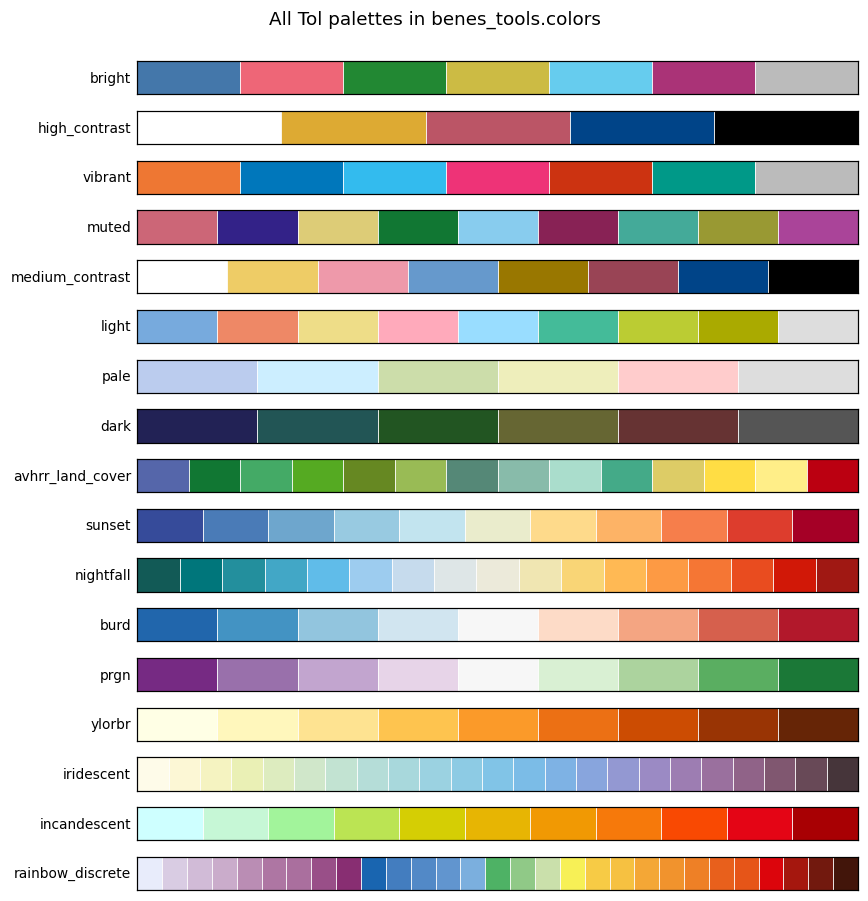

In [2]:
def palette_strip(ax, name, colors):
    n = len(colors)
    for i, c in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=c,
                                   edgecolor='white', lw=0.5))
    ax.set_xlim(0, n); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_ylabel(name, rotation=0, ha='right', va='center', fontsize=9)
    ax.grid(False)

names = list(tol.PALETTES.keys())
fig, axes = plt.subplots(len(names), 1, figsize=(8, 0.45 * len(names) + 0.5))
for ax, name in zip(axes, names):
    palette_strip(ax, name, tol.PALETTES[name])
fig.suptitle("All Tol palettes in benes_tools.colors", y=1.0)
plt.tight_layout(); plt.show()

## 2. Qualitative palette — a few labelled time-series

When we have a *small number of unrelated categories*, we want maximum
distinguishability. `BRIGHT` is Tol's default qualitative palette.

We define four toy signals — a Gaussian pulse, a boxcar, a damped cosine,
and a chirp — and plot them in real space.

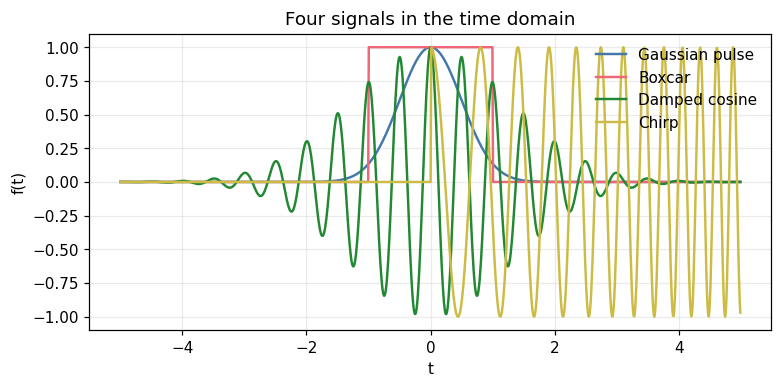

In [3]:
N = 1024
t = np.linspace(-5, 5, N, endpoint=False)
dt = t[1] - t[0]

signals = {
    'Gaussian pulse': np.exp(-t**2 / 0.5),
    'Boxcar'        : ((t > -1) & (t < 1)).astype(float),
    'Damped cosine' : np.exp(-0.3 * t**2) * np.cos(2 * np.pi * 2.0 * t),
    'Chirp'         : np.cos(2 * np.pi * (1.0 * t + 0.3 * t**2)) * (t > 0),
}

fig, ax = plt.subplots(figsize=(8, 3.5))
for (label, y), color in zip(signals.items(), tol.BRIGHT):
    ax.plot(t, y, color=color, lw=1.6, label=label)
ax.set(xlabel='t', ylabel='f(t)', title='Four signals in the time domain')
ax.legend(loc='upper right', frameon=False)
plt.show()

## 3. Same palette, Fourier space

The discrete Fourier transform turns a length-$N$ signal into a length-$N$
spectrum:

$$\hat f_k = \sum_{n=0}^{N-1} f_n\, e^{-2\pi i kn/N}$$

We plot $|\hat f(\omega)|$ for each signal on the same axes — using the
*same* `BRIGHT` colour per signal makes the time/frequency correspondence
obvious at a glance.

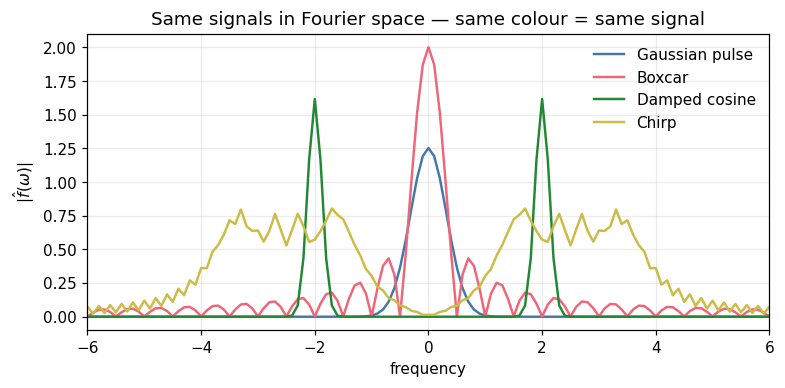

In [4]:
freq = np.fft.fftshift(np.fft.fftfreq(N, d=dt))

fig, ax = plt.subplots(figsize=(8, 3.5))
for (label, y), color in zip(signals.items(), tol.BRIGHT):
    Y = np.fft.fftshift(np.fft.fft(y)) * dt
    ax.plot(freq, np.abs(Y), color=color, lw=1.6, label=label)
ax.set(xlim=(-6, 6), xlabel='frequency', ylabel=r'$|\hat f(\omega)|$',
       title='Same signals in Fourier space — same colour = same signal')
ax.legend(loc='upper right', frameon=False)
plt.show()

## 4. Sequential palette — a spectrogram

Power-like quantities are *non-negative and ordered*. A perceptually-uniform
sequential palette (here `iridescent`) lets the eye read off magnitude as
brightness.

We build a short-time Fourier transform of the chirp.

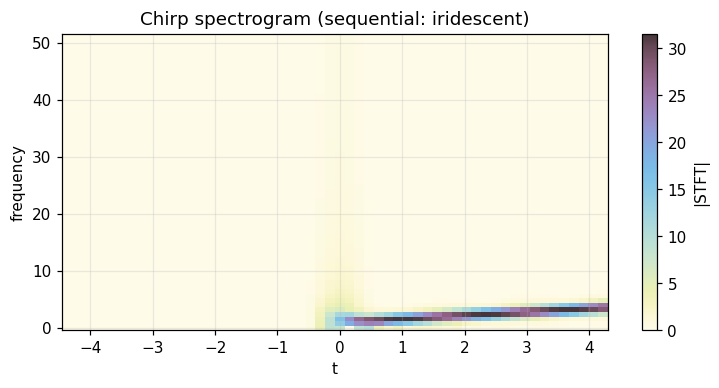

In [5]:
win_len, hop = 128, 16
window = np.hanning(win_len)
chirp = signals['Chirp']
frames, centers = [], []
for start in range(0, N - win_len, hop):
    seg = chirp[start:start + win_len] * window
    frames.append(np.abs(np.fft.rfft(seg)))
    centers.append(t[start + win_len // 2])
S = np.array(frames).T
f_axis = np.fft.rfftfreq(win_len, d=dt)

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.pcolormesh(centers, f_axis, S, cmap=tol.get_cmap('iridescent'),
                   shading='auto')
ax.set(xlabel='t', ylabel='frequency',
       title='Chirp spectrogram (sequential: iridescent)')
fig.colorbar(im, ax=ax, label='|STFT|')
plt.show()

## 5. Diverging palette — signed real part of a 2D FFT

Diverging palettes have a neutral midpoint and grow in opposite directions.
Use them whenever **zero is meaningful** — signed data, anomalies,
deviations from a baseline.

We build a 2D field of cosines (so its FT is real with sharp peaks of either
sign) and visualise $\text{Re}\,\hat f$ with `sunset`, anchored at zero.

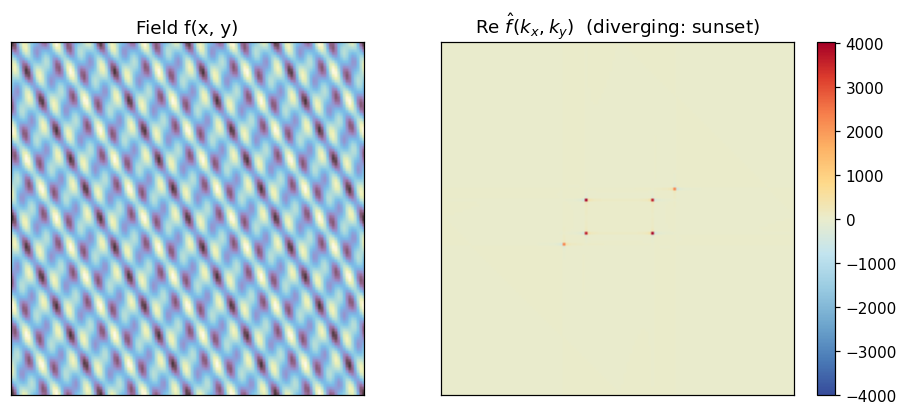

In [6]:
M = 128
x = np.linspace(-1, 1, M)
X, Y = np.meshgrid(x, x)
field = np.cos(2 * np.pi * 6 * X) * np.cos(2 * np.pi * 3 * Y)
field += 0.4 * np.cos(2 * np.pi * 10 * (X + 0.5 * Y))

F = np.fft.fftshift(np.fft.fft2(field))
F_real = np.real(F)
vmax = np.abs(F_real).max()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
axes[0].imshow(field, cmap=tol.get_cmap('iridescent'),
               extent=[-1, 1, -1, 1], origin='lower')
axes[0].set_title('Field f(x, y)')

im = axes[1].imshow(F_real, cmap=tol.get_cmap('sunset'),
                    vmin=-vmax, vmax=vmax, origin='lower')
axes[1].set_title(r'Re $\hat f(k_x, k_y)$  (diverging: sunset)')
fig.colorbar(im, ax=axes[1])
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

### Bonus: showing the `BAD` colour

Every diverging/sequential palette ships with a `BAD` colour for missing data.
Here we mask a disc in the middle and `set_bad` paints it (`get_cmap`
applies it automatically).

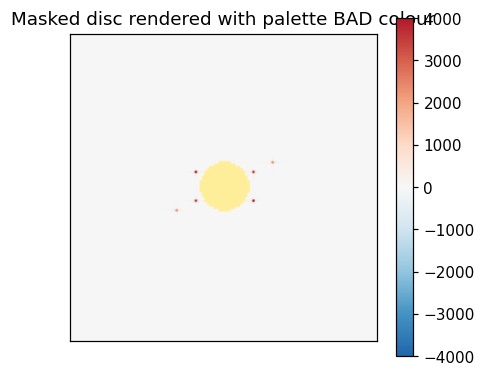

In [7]:
ii, jj = np.indices(F_real.shape)
disc = (ii - M/2)**2 + (jj - M/2)**2 < (M*0.08)**2
F_masked = np.ma.array(F_real, mask=disc)

cmap = tol.get_cmap('burd')  # set_bad('#FFEE99') already applied
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(F_masked, cmap=cmap, vmin=-vmax, vmax=vmax, origin='lower')
ax.set(title='Masked disc rendered with palette BAD colour',
       xticks=[], yticks=[])
ax.grid(False)
fig.colorbar(im, ax=ax)
plt.show()

## 6. Smooth rainbow — a parameter family

When you have a **continuous parameter** and want to show many curves
ordered by it, sample the smooth rainbow. (For a small *discrete* set,
prefer `rainbow_discrete(n)` — it picks well-separated colours.)

Below: the FFT magnitude of a damped cosine as the damping rate varies.

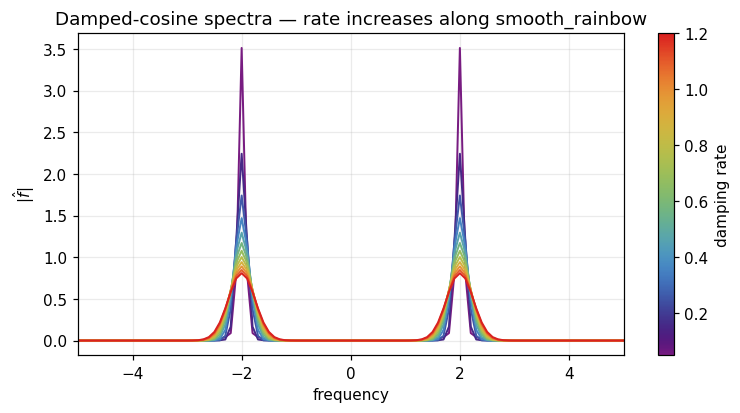

In [8]:
rates = np.linspace(0.05, 1.2, 12)
palette = tol.smooth_rainbow(len(rates))

fig, ax = plt.subplots(figsize=(8, 3.8))
for rate, color in zip(rates, palette):
    y = np.exp(-rate * t**2) * np.cos(2 * np.pi * 2.0 * t)
    Y = np.fft.fftshift(np.fft.fft(y)) * dt
    ax.plot(freq, np.abs(Y), color=color, lw=1.3)
ax.set(xlim=(-5, 5), xlabel='frequency', ylabel=r'$|\hat f|$',
       title='Damped-cosine spectra — rate increases along smooth_rainbow')

sm = plt.cm.ScalarMappable(cmap=tol.get_cmap('smooth_rainbow'),
                           norm=plt.Normalize(rates.min(), rates.max()))
fig.colorbar(sm, ax=ax, label='damping rate')
plt.show()

## 7. AVHRR land-cover palette

A **categorical** palette of 14 land-cover classes (Tol Fig. 27). Related
vegetation types sit in the green band; water (blue), bare (pale yellow),
and urban (red) are sharply distinct.

We build a fake land-cover raster: latitudinal biome bands, two ocean
basins, and scattered patches of cropland and urban.

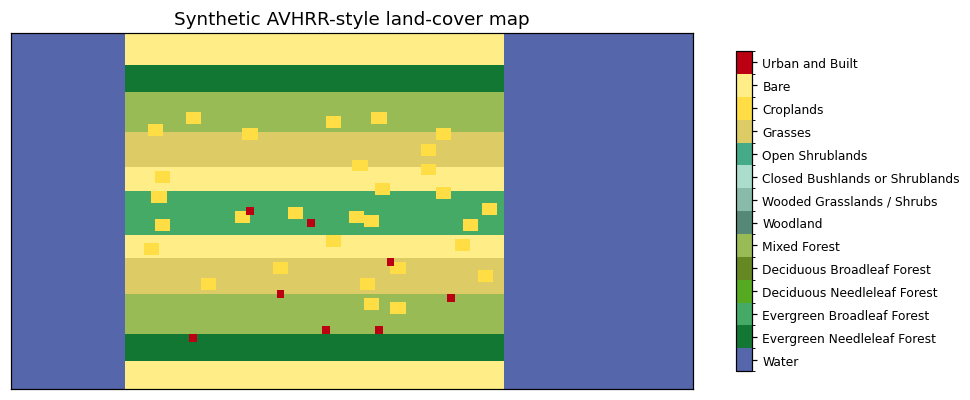

In [9]:
rng = np.random.default_rng(0)
H, W = 90, 180
land = np.zeros((H, W), dtype=int)

# Latitudinal biome bands (very rough caricature)
for j in range(H):
    lat = 90 - 180 * j / H
    if   abs(lat) > 75: land[j, :] = 12  # bare (ice cap)
    elif abs(lat) > 60: land[j, :] = 1   # evergreen needleleaf
    elif abs(lat) > 40: land[j, :] = 5   # mixed forest
    elif abs(lat) > 23: land[j, :] = 10  # grasses
    elif abs(lat) > 10: land[j, :] = 12  # bare (subtropical desert)
    else              : land[j, :] = 2   # evergreen broadleaf

# Two ocean basins
land[:, :30]   = 0
land[:, 130:]  = 0

# Scatter croplands and urban
for _ in range(30):
    i, j = rng.integers(20, H-20), rng.integers(35, 125)
    land[i:i+3, j:j+4] = 11
for _ in range(8):
    i, j = rng.integers(20, H-5), rng.integers(35, 125)
    land[i:i+2, j:j+2] = 13

cmap = tol.get_cmap('avhrr_land_cover')
norm = BoundaryNorm(np.arange(-0.5, 14.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(10, 4.2))
im = ax.imshow(land, cmap=cmap, norm=norm, aspect='auto')
ax.set(title='Synthetic AVHRR-style land-cover map', xticks=[], yticks=[])
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, ticks=np.arange(14), shrink=0.9)
cbar.ax.set_yticklabels(tol.AVHRR_LAND_COVER_LABELS, fontsize=8)
plt.show()

## 8. Cheatsheet — which palette when?

| Data shape                               | Use                                            |
|------------------------------------------|------------------------------------------------|
| ≤ ~7 unrelated labels                    | `BRIGHT` / `VIBRANT` / `MUTED`                 |
| Light-background plots, soft accents     | `LIGHT`, `PALE`                                |
| Print-safe high-contrast                 | `HIGH_CONTRAST`, `MEDIUM_CONTRAST`             |
| 14 land-cover classes                    | `AVHRR_LAND_COVER`                             |
| Non-negative, ordered (magnitude, power) | `IRIDESCENT`, `YLORBR`, `INCANDESCENT`         |
| Signed, zero-centred (anomaly, Re/Im)    | `SUNSET`, `NIGHTFALL`, `BURD`, `PRGN`          |
| Discrete parameter family (≤12)          | `rainbow_discrete(n)`                          |
| Continuous parameter family              | `smooth_rainbow(n)` or `get_cmap('smooth_rainbow')` |

Every palette has a registered `BAD` colour (see `tol.BAD_COLORS`) and is
wired up via `tol.get_cmap('<name>')` for matplotlib.